# ❤️ Proyecto: Predicción de Enfermedades Cardiovasculares

## 🎯 Objetivos del Proyecto

En este proyecto práctico aprenderás a:

1. **Trabajar con datos médicos reales** del UCI Heart Disease Dataset
2. **Construir un pipeline completo** de Machine Learning
3. **Evaluar modelos de clasificación binaria** con múltiples métricas
4. **Comparar diferentes algoritmos** (SGD vs Random Forest)
5. **Registrar experimentos** con MLflow de forma profesional
6. **Interpretar resultados médicos** con responsabilidad

---

## ❤️ ¿Por qué es importante?

Las **Enfermedades Cardiovasculares (ECV)** son la principal causa de muerte en el mundo:

- 💔 Causan **17.9 millones** de muertes al año
- ⚠️ **90% son prevenibles** con detección temprana
- 🏥 Un diagnóstico temprano puede **salvar vidas**
- 🤖 La IA puede ayudar a **detectar patrones** que salven vidas

---

## 📊 El Dataset: UCI Heart Disease

- **303 pacientes** con datos clínicos
- **14 características** médicas (edad, presión arterial, colesterol, etc.)
- **Variable objetivo**: Presencia de enfermedad cardíaca (0/1)
- **Tipo de problema**: Clasificación binaria

---

## 🎓 Ejercicio Especial: Completa los Comentarios

**🚨 IMPORTANTE**: A lo largo de este notebook verás comentarios como:

```python
# TODO: [Completa aquí] ¿Qué hace esta función?
```

**Tu misión** es completar estos comentarios explicando:
- ¿Qué hace el código?
- ¿Por qué es importante?
- ¿Qué resultado esperamos?

Esto te ayudará a:
- ✅ Entender profundamente cada paso
- ✅ Practicar documentación de código
- ✅ Prepararte para proyectos reales

---

## 🚀 ¡Empecemos!

## ⚙️ Paso 2: Configuración de MLflow

Configuramos el experimento donde registraremos todos nuestros entrenamientos.

## 📚 Paso 3: Importar Librerías

Importamos todas las herramientas necesarias para el proyecto.

In [0]:
import mlflow
import warnings
warnings.filterwarnings('ignore')

mlflow.set_tracking_uri("databricks")
mlflow.set_registry_uri("databricks")

email = 'carrascoalvarezgonzalo@gmail.com'

# Validación
if not email:
    print("⚠️  ADVERTENCIA: Debes configurar tu email antes de continuar")
else:
    # Selecciona databricks como tracking server
    mlflow.set_tracking_uri("databricks")
    
    # Crea un experimento donde se guardan las runs
    experiment_name = f"/Users/{email}/5-prediccion-infarto"
    mlflow.set_experiment(experiment_name)
    
    print("=" * 70)
    print("✅ MLflow configurado correctamente")
    print("=" * 70)
    print(f"📊 Experimento: {experiment_name}")
    print(f"❤️  Proyecto: Predicción de Enfermedades Cardiovasculares")
    print("=" * 70)

✅ MLflow configurado correctamente
📊 Experimento: /Users/carrascoalvarezgonzalo@gmail.com/5-prediccion-infarto
❤️  Proyecto: Predicción de Enfermedades Cardiovasculares


In [0]:
# Librerías básicas
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Dividir los datos en train y test sets
from sklearn.model_selection import train_test_split

# Sirve para encadenar procesos
from sklearn.pipeline import Pipeline

# Preprocesamiento
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

# Dos clasificadores, un random forest y un sgd
from sklearn.linear_model import SGDClassifier
from sklearn.ensemble import RandomForestClassifier

# Sirve para obtener una estimación más fiable del rendimiento del modelo
from sklearn.model_selection import cross_val_score, cross_val_predict

from sklearn.metrics import (
    precision_score, # De las predicciones de enfermo, cuantos realmente lo están
    recall_score, # De los enfermos que hay, cuantos detecta el modelo
    f1_score, # Combinación de precision y recall
    confusion_matrix, # Matriz para visualizar errores y aciertos del modelo
    ConfusionMatrixDisplay, 
    roc_auc_score, # Capacidad del modelo para distinguir las clases
    accuracy_score, # Predicciones correctas
    classification_report, # Resumen de métricas
    roc_curve # Sirve para representar la curva ROC
)

# Configuración de visualización
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")

print("✅ Todas las librerías importadas correctamente")

✅ Todas las librerías importadas correctamente


## ❤️ Contexto del Proyecto

### El Problema

En este proyecto trabajaremos con el **UCI Heart Disease Dataset**, uno de los datasets más importantes en medicina predictiva. 

### 📊 Datos Clave sobre ECV

- 💔 **Principal causa de muerte** a nivel mundial
- 📈 **17.9 millones** de muertes anuales
- ⚠️ **90% son prevenibles** con detección temprana
- 🎯 **Diagnóstico temprano** = vidas salvadas
- 🤖 **IA** puede detectar patrones imperceptibles para humanos

### 🎯 Nuestro Objetivo

Construir un modelo de Machine Learning que pueda **predecir la presencia de enfermedad cardiovascular** basándose en características clínicas del paciente.

### ⚕️ Responsabilidad Ética

> ⚠️ **IMPORTANTE**: Este es un proyecto educativo. Los modelos médicos reales requieren:
> - Validación clínica exhaustiva
> - Aprobación regulatoria
> - Supervisión médica profesional
> - Consideraciones éticas y legales

Nuestro objetivo es aprender las técnicas, no reemplazar el criterio médico.

## 📚 Fundamentos: Clasificación Binaria

### 🎯 ¿Qué es Clasificación Binaria?

Un problema donde el modelo debe elegir entre **dos clases**:
- ✅ Clase Positiva (1): Tiene enfermedad cardíaca
- ❌ Clase Negativa (0): No tiene enfermedad cardíaca

---

### 🔄 Pipeline de Entrenamiento

```
1. Preparación de Datos
   ↓
2. Selección del Modelo
   ↓
3. Entrenamiento
   ↓
4. Ajuste de Hiperparámetros
   ↓
5. Evaluación
```

---

### 📊 Métricas de Evaluación

#### 1. **Matriz de Confusión**

|                    | Predicción: No (0) | Predicción: Sí (1) |
|--------------------|--------------------|--------------------|
| **Real: No (0)**   | TN (Verdadero Neg) | FP (Falso Positivo)|
| **Real: Sí (1)**   | FN (Falso Negativo)| TP (Verdadero Pos) |

#### 2. **Precision (Precisión)**
```
Precision = TP / (TP + FP)
```
- "De los que predije como enfermos, ¿cuántos realmente lo están?"
- **Importante cuando**: Los falsos positivos son costosos

#### 3. **Recall (Sensibilidad)**
```
Recall = TP / (TP + FN)
```
- "De todos los enfermos reales, ¿cuántos detecté?"
- **Importante cuando**: No podemos perder ningún caso positivo (medicina)

#### 4. **F1-Score**
```
F1 = 2 × (Precision × Recall) / (Precision + Recall)
```
- Balance entre Precision y Recall
- Útil cuando las clases están desbalanceadas

#### 5. **ROC-AUC**
- Curva ROC: Representa el trade-off entre True Positive Rate y False Positive Rate
- AUC: Área bajo la curva (0.5 = aleatorio, 1.0 = perfecto)

#### 6. **Validación Cruzada**
- Divide datos en K partes (folds)
- Entrena K veces, cada vez con un fold diferente como test
- Promedia resultados para obtener estimación robusta

---

### 🎯 ¿Qué métrica usar?

| Situación | Métrica Principal |
|-----------|-------------------|
| Clases balanceadas | Accuracy |
| No perder positivos (medicina) | **Recall** ⭐ |
| Evitar falsos positivos | Precision |
| Balance general | F1-Score |
| Comparar modelos | ROC-AUC |

**En medicina, típicamente priorizamos Recall** porque es mejor detectar un caso falso positivo que perder un verdadero positivo.

## 📁 Paso 4: Cargar y Explorar los Datos

Cargamos el dataset y realizamos un análisis exploratorio inicial.

In [0]:
# Cargamos los datos de heart.csv, que contiene las filas y columnas del dataset
data = pd.read_csv('../data/raw/heart.csv')

print("=" * 70)
print("❤️  DATASET CARGADO: UCI HEART DISEASE")
print("=" * 70)
print(f"📊 Número de muestras: {len(data)}")
print(f"📈 Número de características: {len(data.columns) - 1}")  # -1 porque target no es característica
print(f"🎯 Variable objetivo: target (0 = No enfermedad, 1 = Enfermedad)")
print("=" * 70)

❤️  DATASET CARGADO: UCI HEART DISEASE
📊 Número de muestras: 303
📈 Número de características: 13
🎯 Variable objetivo: target (0 = No enfermedad, 1 = Enfermedad)


In [0]:
# head() muestra las primeras filas del dataset, sirve para visualizar la estructura del dataset y hacerse una idea rápida
print("🔍 Primeras 5 filas del dataset:\n")
data.head()

🔍 Primeras 5 filas del dataset:



,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,Male,asymptomatic,145.0,233.0,True,normal,150,No,2.3,upsloping,0,1,1
1,37,Male,non-anginal pain,NaN,250.0,False,having ST-T wave abnormality,187,No,3.5,upsloping,0,2,1
2,41,Female,atypical angina,NaN,204.0,False,normal,172,No,1.4,downsloping,0,2,1
3,56,Male,atypical angina,120.0,236.0,False,having ST-T wave abnormality,178,No,0.8,downsloping,0,2,1
4,57,Female,typical angina,120.0,NaN,False,having ST-T wave abnormality,163,Yes,0.6,downsloping,0,2,1


### 📋 Diccionario de Datos

Cada columna representa una característica médica importante:

#### 👤 Datos Demográficos
1. **age**: Edad del paciente en años
2. **sex**: Sexo (1 = masculino, 0 = femenino)

#### 💊 Síntomas y Diagnóstico
3. **cp**: Tipo de dolor de pecho (Chest Pain)
   - 0: Angina típica
   - 1: Angina atípica
   - 2: Dolor no anginoso
   - 3: Asintomático

4. **exang**: Angina inducida por ejercicio (1 = sí, 0 = no)

#### 🩺 Mediciones Clínicas
5. **trestbps**: Presión arterial en reposo (mm Hg)
6. **chol**: Colesterol sérico (mg/dl)
7. **fbs**: Azúcar en sangre en ayunas > 120 mg/dl (1 = verdadero, 0 = falso)
8. **thalach**: Frecuencia cardíaca máxima alcanzada

#### 📊 Resultados de Pruebas
9. **restecg**: Resultados electrocardiográficos en reposo
   - 0: Normal
   - 1: Anormalidad de onda ST-T
   - 2: Hipertrofia ventricular izquierda

10. **oldpeak**: Depresión del segmento ST inducida por ejercicio

11. **slope**: Pendiente del segmento ST durante ejercicio
    - 0: Ascendente
    - 1: Plano
    - 2: Descendente

12. **ca**: Número de vasos principales coloreados por fluoroscopia (0-3)

13. **thal**: Resultados de prueba de talasemia
    - 1: Normal
    - 2: Defecto fijo
    - 3: Defecto reversible

#### 🎯 Variable Objetivo
14. **target**: Presencia de enfermedad cardíaca
    - 0: No enfermedad
    - 1: Enfermedad presente

---

**💡 Tip**: En medicina, cada una de estas características tiene significado clínico. Un buen data scientist debe entender el dominio del problema.

In [0]:
# Resumen del dataset, como los tipos de datos, valores nulos etc.
print("ℹ️  Información general del dataset:\n")
data.info()

ℹ️  Información general del dataset:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    object 
 2   cp        303 non-null    object 
 3   trestbps  258 non-null    float64
 4   chol      273 non-null    float64
 5   fbs       303 non-null    bool   
 6   restecg   303 non-null    object 
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    object 
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    object 
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: bool(1), float64(3), int64(5), object(5)
memory usage: 31.2+ KB


In [0]:
# Muestra número de valores, media, desviación estándar, valores mínimos y máximos y los percentiles
print("📊 Estadísticas descriptivas:\n")
data.describe()

📊 Estadísticas descriptivas:



,age,trestbps,chol,thalach,oldpeak,ca,thal,target
count,303.000000,258.000000,273.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,131.465116,245.871795,149.646865,1.039604,0.729373,2.313531,0.544554
std,9.082101,16.914317,52.528792,22.905161,1.161075,1.022606,0.612277,0.498835
min,29.000000,94.000000,131.000000,71.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,120.000000,209.000000,133.500000,0.000000,0.000000,2.000000,0.000000
50%,55.000000,130.000000,240.000000,153.000000,0.800000,0.000000,2.000000,1.000000
75%,61.000000,140.000000,275.000000,166.000000,1.600000,1.000000,3.000000,1.000000
max,77.000000,200.000000,564.000000,202.000000,6.200000,4.000000,3.000000,1.000000


### 💡 Observaciones Clave

**TODO: [Completa aquí] Basándote en las estadísticas, ¿qué observaciones puedes hacer sobre:**
- La edad media de los pacientes
- El rango de valores de cada característica
- La presencia de valores nulos
- Características que pueden necesitar normalización

In [0]:
# Analizar la distribución es clave para comprobar si el dataset está balanceado para un entrenamiento menos sesgado
print("🎯 Distribución de la variable objetivo:\n")
target_counts = data.target.value_counts()
print(target_counts)
print(f"\nProporción:")
print(f"  - Sin enfermedad (0): {target_counts[0]/len(data)*100:.1f}%")
print(f"  - Con enfermedad (1): {target_counts[1]/len(data)*100:.1f}%")

# Está balanceado, si no lo estuviera, el modelo aprendería a predecir en la mayoría de casos a la clase mayoritaria
balance_ratio = min(target_counts) / max(target_counts)
if balance_ratio > 0.8:
    print(f"\n✅ Dataset balanceado (ratio: {balance_ratio:.2f})")
else:
    print(f"\n⚠️  Dataset desbalanceado (ratio: {balance_ratio:.2f})")

🎯 Distribución de la variable objetivo:

target
1    165
0    138
Name: count, dtype: int64

Proporción:
  - Sin enfermedad (0): 45.5%
  - Con enfermedad (1): 54.5%

✅ Dataset balanceado (ratio: 0.84)


### 🔍 Análisis Exploratorio Visual

Visualicemos las relaciones entre características para entender mejor los datos.

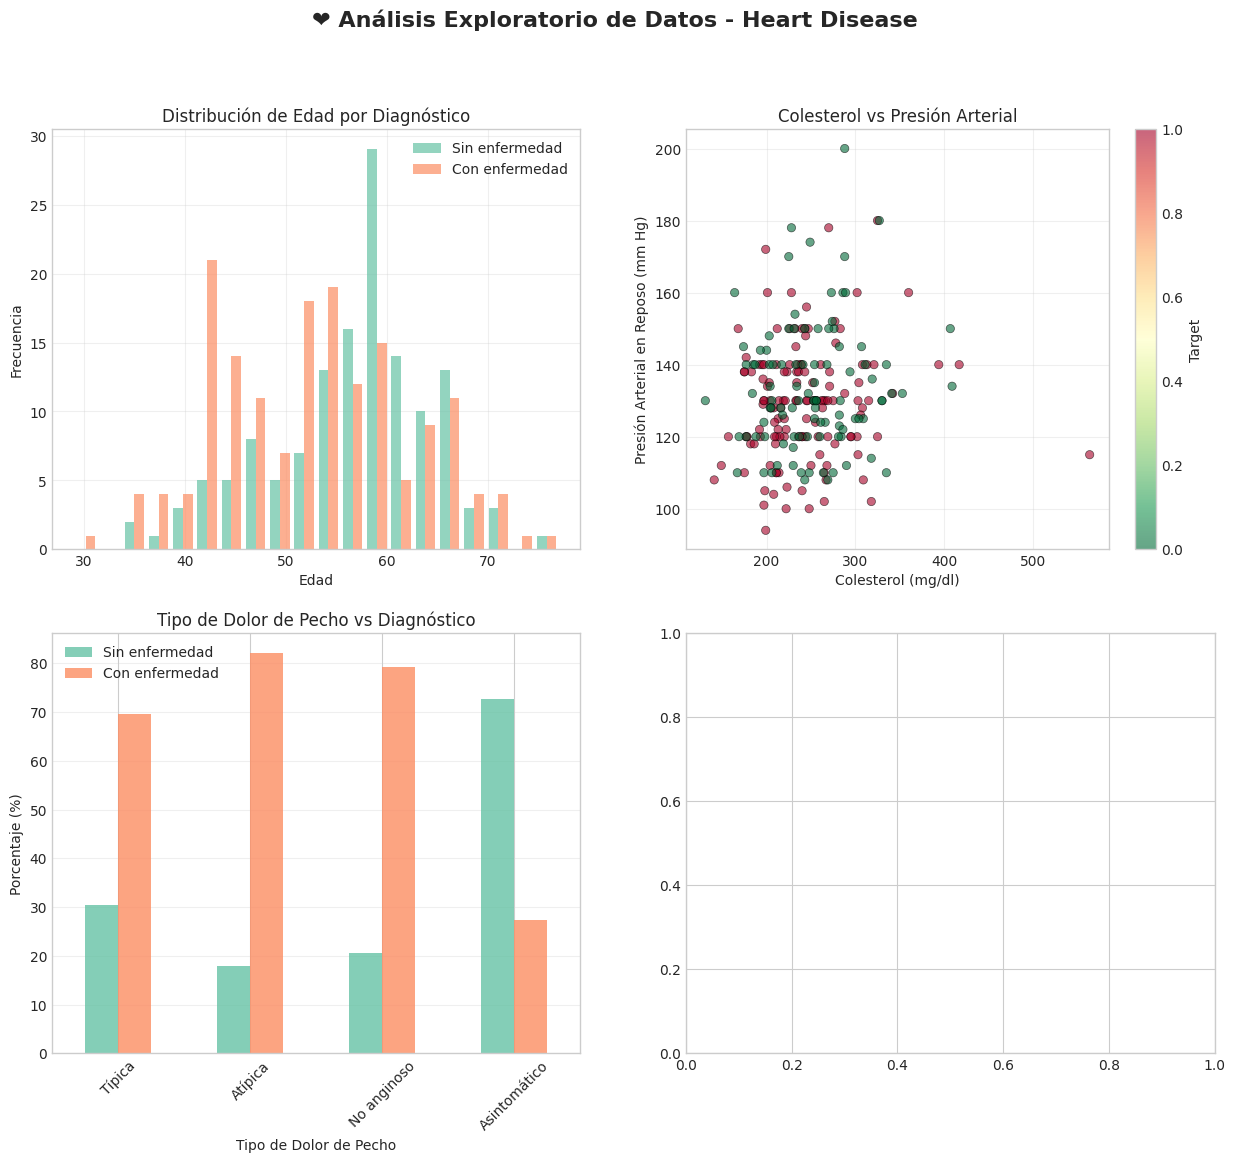

---------------------------------------------------------------------------
ValueError                                Traceback (most recent call last)
File <command-4969757457608272>, line 37
     35 # Gráfico 4: Matriz de correlación (top 10 características)
     36 top_features = ['age', 'sex', 'cp', 'trestbps', 'chol', 'thalach', 'exang', 'oldpeak', 'ca', 'target']
---> 37 corr_matrix = data[top_features].corr()
     38 sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
     39             ax=axes[1, 1], cbar_kws={'label': 'Correlación'})
     40 axes[1, 1].set_title('Matriz de Correlación')

File /databricks/python/lib/python3.12/site-packages/pandas/core/frame.py:11049, in DataFrame.corr(self, method, min_periods, numeric_only)
  11047 cols = data.columns
  11048 idx = cols.copy()
> 11049 mat = data.to_numpy(dtype=float, na_value=np.nan, copy=False)
  11051 if method == "pearson":
  11052     correl = libalgos.nancorr(mat, minp=min_periods)

File /databricks/python

In [0]:
# De las visualizaciones se pueden sacar relaciones y patrones entre las características de los pacientes

# Crear figura con múltiples subplots
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('❤️ Análisis Exploratorio de Datos - Heart Disease', fontsize=16, fontweight='bold')

# Gráfico 1: Distribución de edad por target
axes[0, 0].hist([data[data.target==0]['age'], data[data.target==1]['age']], 
                bins=20, label=['Sin enfermedad', 'Con enfermedad'], alpha=0.7)
axes[0, 0].set_xlabel('Edad')
axes[0, 0].set_ylabel('Frecuencia')
axes[0, 0].set_title('Distribución de Edad por Diagnóstico')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Gráfico 2: Colesterol vs Presión Arterial
scatter = axes[0, 1].scatter(data['chol'], data['trestbps'], c=data['target'], 
                             alpha=0.6, cmap='RdYlGn_r', edgecolors='black', linewidth=0.5)
axes[0, 1].set_xlabel('Colesterol (mg/dl)')
axes[0, 1].set_ylabel('Presión Arterial en Reposo (mm Hg)')
axes[0, 1].set_title('Colesterol vs Presión Arterial')
plt.colorbar(scatter, ax=axes[0, 1], label='Target')
axes[0, 1].grid(True, alpha=0.3)

# Gráfico 3: Tipo de dolor de pecho por diagnóstico
cp_target = pd.crosstab(data['cp'], data['target'], normalize='index') * 100
cp_target.plot(kind='bar', ax=axes[1, 0], alpha=0.8)
axes[1, 0].set_xlabel('Tipo de Dolor de Pecho')
axes[1, 0].set_ylabel('Porcentaje (%)')
axes[1, 0].set_title('Tipo de Dolor de Pecho vs Diagnóstico')
axes[1, 0].legend(['Sin enfermedad', 'Con enfermedad'])
axes[1, 0].set_xticklabels(['Típica', 'Atípica', 'No anginoso', 'Asintomático'], rotation=45)
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Gráfico 4: Matriz de correlación (top 10 características)
top_features = ['age', 'sex', 'cp', 'trestbps', 'chol', 'thalach', 'exang', 'oldpeak', 'ca', 'target']
corr_matrix = data[top_features].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            ax=axes[1, 1], cbar_kws={'label': 'Correlación'})
axes[1, 1].set_title('Matriz de Correlación')

plt.tight_layout()
plt.show()

print("✅ Visualizaciones generadas")
print("\n Se observa que el dolor de pecho asintomático en la mayoría de casos no está provocado por una enfermedad.")
print("También se aprecia que la frecuencia suele ser mayor cuando hay enfermedad, salvo en edades del rango de 60-70 años")

## 🔀 Paso 5: Dividir los Datos

Dividimos el dataset en conjuntos de entrenamiento y prueba.

In [0]:
# Dividir en 2 sets es crucial para evaluar al modelo de manera realista
# El test size indica que porción del dataset formará el test set, el random state indica la semilla para reproducibilidad
train_set, test_set = train_test_split(data, test_size=0.2, random_state=5)

print("=" * 70)
print("🔀 DIVISIÓN DE DATOS")
print("=" * 70)
print(f"📊 Total de muestras: {len(data)}")
print(f"📚 Conjunto de entrenamiento: {len(train_set)} ({len(train_set)/len(data)*100:.1f}%)")
print(f"🧪 Conjunto de prueba: {len(test_set)} ({len(test_set)/len(data)*100:.1f}%)")
print("=" * 70)
print("✅ Datos divididos correctamente")

In [0]:
# Los histogramas muestran las distribuciones de las características
# Sirven para saber que valores toman las características en su mayoría y a que rangos pertenecen
print("📊 Generando histogramas de distribuciones...\n")
train_set.hist(bins=50, figsize=(20, 15))
plt.suptitle('Distribución de Características - Conjunto de Entrenamiento', fontsize=16, y=1.00)
plt.tight_layout()
plt.show()

print("Se aprecia como chl, trestbps, age y thalach tienen escalas muy diferentes al resto")

### 📏 Observación Importante: Escalas Diferentes

**¿Por qué es un problema que las características tengan escalas diferentes?**
Porque el modelo puede dar prioridad a un valor simplemente por ser mas grande que otro debido a la diferencia de escalas

Las características tienen diferentes escalas:
- **age**: 29-77 años
- **trestbps**: 94-200 mm Hg
- **chol**: 126-564 mg/dl
- **thalach**: 71-202

**Solución**: Aplicaremos **Standard Scaling** (estandarización) para que todas las características tengan:
- Media = 0
- Desviación estándar = 1

**¿Por qué esto ayuda a los modelos de Machine Learning?**
Porque así todos los valores tienen el mismo "peso" para el modelo

## 🔧 Paso 6: Construir el Pipeline de Preprocesamiento

Crearemos un pipeline que prepare los datos automáticamente.

In [0]:
# Las variables categóricas son las que representan una categoría, es decir, no tienen valores numéricos
# Las variables numéricas son las que tienen valores numéricos (por ejemplo la edad se representa con un número)
cat_attr = ["sex", "cp", "fbs", "restecg", "exang", "slope"]
num_attr = ["age", "trestbps", "chol", "thalach", "oldpeak", "ca", "thal"]

print("📋 Clasificación de variables:")
print(f"   📊 Numéricas ({len(num_attr)}): {num_attr}")
print(f"   🏷️  Categóricas ({len(cat_attr)}): {cat_attr}")

# Rellena los valores faltantes del dataset, usamos la mediana porque es más robusta que la media para valores atípicos
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),  # Rellenar valores nulos
    ("std_scaler", StandardScaler())                # Estandarizar
])

# Sirve para realizar transformaciones a las columnas, lo necesitamos porque las transformaciones a realizar varían según sea categórica o numérica
full_pipeline = ColumnTransformer([
    ("num", num_pipeline, num_attr),      # Pipeline para numéricas
    ("cat", OneHotEncoder(), cat_attr)    # One-Hot Encoding para categóricas
])

print("\n✅ Pipeline de preprocesamiento creado")
print("\n💡 El pipeline:")
print("   1. Rellena valores nulos con la mediana (numéricas)")
print("   2. Estandariza variables numéricas (media=0, std=1)")
print("   3. Aplica One-Hot Encoding a variables categóricas")
print("\n¿Por qué One-Hot Encoding para categóricas?: Porque transforma las categóricas en valores numéricos entendibles para el modelo")

## 🎯 Paso 7: Preparar X e y

Separamos características (X) de la variable objetivo (y).

In [0]:
# Se separa X de y porque para que el modelo produzca una salida se necesita solo X
# Para que el modelo se ajuste a los datos necesita y
x_train = train_set.drop("target", axis=1)  # Características
y_train = train_set.target                   # Variable objetivo

print("=" * 70)
print("🎯 SEPARACIÓN DE CARACTERÍSTICAS Y TARGET")
print("=" * 70)
print(f"X_train shape: {x_train.shape} (características)")
print(f"y_train shape: {y_train.shape} (target)")
print("=" * 70)

In [0]:
# Fit transform se ajusta a los datos y los transforma. Transform simplemente los transforma con los datos ajustados previamente
# Especialmente útil para prevenir el data leakage
x_train_pr = full_pipeline.fit_transform(x_train)

print("🔧 Pipeline aplicado al conjunto de entrenamiento")
print(f"   Shape original: {x_train.shape}")
print(f"   Shape procesado: {x_train_pr.shape}")
print(f"\n¿Por qué cambió el número de columnas?: Porque el one hot encoder crea una columna por cada categoría")

## 🤖 Paso 8: Entrenamiento y Evaluación de Modelos

Entrenaremos dos modelos y compararemos sus resultados usando MLflow.

### 🔵 Modelo 1: SGD Classifier (Baseline)

**TODO: [Completa aquí] ¿Qué es SGD (Stochastic Gradient Descent) y cómo funciona?**

Empezaremos con un modelo simple como baseline (línea base) para tener una referencia.

In [0]:
# Activar autolog de MLflow
mlflow.sklearn.autolog()

# Iniciar experimento con MLflow
with mlflow.start_run(run_name="SGD Classifier - Baseline") as run:
    
    print("=" * 70)
    print("🚀 ENTRENANDO MODELO BASELINE: SGD CLASSIFIER")
    print("=" * 70)
    
    # Random state es la semilla de la aleatoriedad y se fija para la reproducibilidad
    sgd_clf = SGDClassifier(random_state=42)
    
    # Se divide el train test en 3 sets iguales y en cada fold se alterna el conjunto de validación, el resto de sets se usan de entrenamiento en ese fold
    print("\n🔄 Realizando validación cruzada (3-fold)...")
    scores = cross_val_score(sgd_clf, x_train_pr, y_train, cv=3, scoring="accuracy")
    
    print(f"\n📊 Accuracy por fold:")
    for i, score in enumerate(scores, 1):
        print(f"   Fold {i}: {score:.4f} ({score*100:.2f}%)")
    
    print(f"\n📈 Accuracy promedio: {scores.mean():.4f} ± {scores.std():.4f}")
    
    # Registrar métrica en MLflow
    mlflow.log_metric("cv_accuracy_mean", scores.mean())
    mlflow.log_metric("cv_accuracy_std", scores.std())
    
    print("\n✅ Modelo SGD entrenado con validación cruzada")
    print("=" * 70)

### 📊 Evaluación del Modelo SGD

In [0]:
# Se usa cross val predict para que las predicciones sean sobre el conjunto no usado durante el entrenamiento
print("🔮 Obteniendo predicciones con validación cruzada...")
preds = cross_val_predict(sgd_clf, x_train_pr, y_train, cv=3)
print(f"✅ {len(preds)} predicciones generadas")

In [0]:
# La matriz de confusión muestra las predicciones del modelo y los valores reales. Facilitando su interpretación
print("📊 Generando matriz de confusión...\n")

cm = confusion_matrix(y_train, preds)
disp = ConfusionMatrixDisplay(cm, display_labels=['Sin enfermedad', 'Con enfermedad'])
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, cmap='Blues')
plt.title('Matriz de Confusión - SGD Classifier', fontsize=14, fontweight='bold')
plt.grid(False)
plt.show()

print(f"\n📋 Interpretación de la matriz:")
print(f"   TN (Verdaderos Negativos): {cm[0,0]} - Correctamente identificados como sanos")
print(f"   FP (Falsos Positivos): {cm[0,1]} - Sanos clasificados como enfermos")
print(f"   FN (Falsos Negativos): {cm[1,0]} - Enfermos clasificados como sanos ⚠️")
print(f"   TP (Verdaderos Positivos): {cm[1,1]} - Correctamente identificados como enfermos")
print(f"\n¿Qué tipo de error es más grave en medicina?: En medicina los falsos negativos son los más críticos, ya que pueden llevar a que una enfermedad no se trate")

In [0]:
print("=" * 70)
print("📊 MÉTRICAS DEL MODELO SGD")
print("=" * 70)

precision = precision_score(y_train, preds)
recall = recall_score(y_train, preds)
f1 = f1_score(y_train, preds)
roc_auc = roc_auc_score(y_train, preds)

print(f"🎯 Precision: {precision:.4f} ({precision*100:.2f}%)")
print(f"   → De los que predije como enfermos, el {precision*100:.1f}% realmente lo están")
print(f"\n❤️  Recall: {recall:.4f} ({recall*100:.2f}%)")
print(f"   → Detecté el {recall*100:.1f}% de todos los enfermos reales")
print(f"\n⚖️  F1 Score: {f1:.4f}")
print(f"   → Balance entre precision y recall")
print(f"\n📈 ROC-AUC Score: {roc_auc:.4f}")
print(f"   → Capacidad de discriminación del modelo")
print("=" * 70)

print("\n ¿Qué métrica es más importante en medicina y por qué?: El recall es la más importante porque indica cuantos casos de enfermedades reales a conseguido detectar")

### 🌲 Modelo 2: Random Forest Classifier

**TODO: [Completa aquí] ¿Qué es Random Forest y por qué suele funcionar mejor que modelos simples?**

Ahora probemos un modelo más potente y comparemos resultados.

In [0]:
# Continuar con MLflow (nuevo run para Random Forest)
with mlflow.start_run(run_name="Random Forest Classifier") as run:
    
    print("=" * 70)
    print("🚀 ENTRENANDO MODELO: RANDOM FOREST CLASSIFIER")
    print("=" * 70)
    
    # ¿Qué hiperparámetros podríamos ajustar en Random Forest?: n_estimators, max_depth...
    rf_clf = RandomForestClassifier(random_state=42)
    
    # ¿Por qué volvemos a hacer validación cruzada?: Para poder comparar modelos de una manera justa
    print("\n🔄 Realizando validación cruzada (3-fold)...")
    rf_scores = cross_val_score(rf_clf, x_train_pr, y_train, cv=3, scoring="accuracy")
    
    print(f"\n📊 Accuracy por fold:")
    for i, score in enumerate(rf_scores, 1):
        print(f"   Fold {i}: {score:.4f} ({score*100:.2f}%)")
    
    print(f"\n📈 Accuracy promedio: {rf_scores.mean():.4f} ± {rf_scores.std():.4f}")
    
    # Obtener predicciones
    rf_preds = cross_val_predict(rf_clf, x_train_pr, y_train, cv=3)
    
    # Registrar en MLflow
    mlflow.log_metric("cv_accuracy_mean", rf_scores.mean())
    mlflow.log_metric("cv_accuracy_std", rf_scores.std())
    
    print("\n✅ Modelo Random Forest entrenado")
    print("=" * 70)

In [0]:
print("📊 Matriz de Confusión - Random Forest\n")

cm_rf = confusion_matrix(y_train, rf_preds)
disp_rf = ConfusionMatrixDisplay(cm_rf, display_labels=['Sin enfermedad', 'Con enfermedad'])
fig, ax = plt.subplots(figsize=(8, 6))
disp_rf.plot(ax=ax, cmap='Greens')
plt.title('Matriz de Confusión - Random Forest', fontsize=14, fontweight='bold')
plt.grid(False)
plt.show()

print(f"\n📋 Interpretación:")
print(f"   TN: {cm_rf[0,0]} | FP: {cm_rf[0,1]}")
print(f"   FN: {cm_rf[1,0]} | TP: {cm_rf[1,1]}")
print(f"\n ¿Mejoró respecto a SGD? ¿En qué?: Tiene mayor accuracy pero tiene peor recall")

In [0]:
print("=" * 70)
print("📊 MÉTRICAS DEL MODELO RANDOM FOREST")
print("=" * 70)

rf_precision = precision_score(y_train, rf_preds)
rf_recall = recall_score(y_train, rf_preds)
rf_f1 = f1_score(y_train, rf_preds)
rf_roc_auc = roc_auc_score(y_train, rf_preds)

print(f"🎯 Precision: {rf_precision:.4f} ({rf_precision*100:.2f}%)")
print(f"❤️  Recall: {rf_recall:.4f} ({rf_recall*100:.2f}%)")
print(f"⚖️  F1 Score: {rf_f1:.4f}")
print(f"📈 ROC-AUC Score: {rf_roc_auc:.4f}")
print("=" * 70)

# Comparación con SGD
print("\n📊 COMPARACIÓN SGD vs RANDOM FOREST")
print("=" * 70)
comparison = pd.DataFrame({
    'Métrica': ['Precision', 'Recall', 'F1-Score', 'ROC-AUC'],
    'SGD': [precision, recall, f1, roc_auc],
    'Random Forest': [rf_precision, rf_recall, rf_f1, rf_roc_auc],
    'Diferencia': [
        rf_precision - precision,
        rf_recall - recall,
        rf_f1 - f1,
        rf_roc_auc - roc_auc
    ]
})
print(comparison.to_string(index=False))
print("=" * 70)

print("\n ¿Qué modelo funciona mejor y por qué?: Random forest es superior en todas las métricas salvo recall. Aunque recall sea la métrica más importante se debe tener en cuenta que la diferencia en recall es mínima.")

## 🎯 Paso 9: Entrenamiento Final y Evaluación en Test

Ahora entrenaremos el modelo con **todo el conjunto de entrenamiento** y evaluaremos en el conjunto de prueba (que nunca ha visto).

In [0]:
# Entrenamos con todos los datos de train porque ya no hace falta validación cruzada, debido a que ya hemos elegido el modelo
print("🎯 Entrenamiento final con todo el conjunto de entrenamiento\n")

forest_clf = RandomForestClassifier(random_state=42)
forest_clf.fit(x_train_pr, y_train)

print("✅ Modelo Random Forest entrenado con", len(x_train_pr), "muestras")
print("📊 El modelo ahora tiene más datos para aprender patrones")

In [0]:
x_test = test_set.drop("target", axis=1)
y_test = test_set.target

print("🧪 Conjunto de prueba preparado:")
print(f"   X_test: {x_test.shape}")
print(f"   y_test: {y_test.shape}")

In [0]:
# ¿Por qué usamos transform() y no fit_transform()?: Para evitar data leakage, usar fit_transform estaría aportando información del test al modelo de manera indirecta
x_test_pr = full_pipeline.transform(x_test)
final_preds = forest_clf.predict(x_test_pr)

print("🔮 Predicciones en conjunto de prueba generadas")
print(f"   Datos procesados: {x_test_pr.shape}")
print(f"   Predicciones: {len(final_preds)}")

In [0]:
# ¿Qué significan estos resultados en el conjunto de prueba?: Son los resultados con información que el modelo no ha visto antes
# Por ello nos indican cómo se comportará el modelo en situaciones reales
print("=" * 70)
print("🎉 RESULTADOS FINALES EN CONJUNTO DE PRUEBA")
print("=" * 70)

final_precision = precision_score(y_test, final_preds)
final_recall = recall_score(y_test, final_preds)
final_f1 = f1_score(y_test, final_preds)
final_roc_auc = roc_auc_score(y_test, final_preds)
final_accuracy = accuracy_score(y_test, final_preds)

print(f"🎯 Accuracy: {final_accuracy:.4f} ({final_accuracy*100:.2f}%)")
print(f"🎯 Precision: {final_precision:.4f} ({final_precision*100:.2f}%)")
print(f"❤️  Recall: {final_recall:.4f} ({final_recall*100:.2f}%)")
print(f"⚖️  F1 Score: {final_f1:.4f}")
print(f"📈 ROC-AUC: {final_roc_auc:.4f}")
print("=" * 70)

# Matriz de confusión final
print("\n📊 Matriz de Confusión Final:\n")
cm_final = confusion_matrix(y_test, final_preds)
disp_final = ConfusionMatrixDisplay(cm_final, display_labels=['Sin enfermedad', 'Con enfermedad'])
fig, ax = plt.subplots(figsize=(8, 6))
disp_final.plot(ax=ax, cmap='YlGnBu')
plt.title('Matriz de Confusión - Conjunto de Prueba', fontsize=14, fontweight='bold')
plt.grid(False)
plt.show()

# Reporte de clasificación completo
print("\n📋 REPORTE DE CLASIFICACIÓN DETALLADO:")
print("=" * 70)
print(classification_report(y_test, final_preds, 
                          target_names=['Sin enfermedad', 'Con enfermedad'],
                          digits=4))
print("=" * 70)

print("\n ¿El modelo generaliza bien? ¿Cómo lo sabes?: Sí, porque los resultados del test son similares, incluso mejores que los de la validación cruzada")

## 🎉 ¡Proyecto Completado!

### ✅ Lo que Hemos Logrado

1. ✅ **Explorado datos médicos reales** con análisis visual
2. ✅ **Construido un pipeline completo** de preprocesamiento
3. ✅ **Entrenado y comparado** 2 modelos (SGD y Random Forest)
4. ✅ **Evaluado con múltiples métricas** de clasificación
5. ✅ **Usado validación cruzada** para validación robusta
6. ✅ **Registrado experimentos** en MLflow
7. ✅ **Interpretado resultados** con matrices de confusión

### 📊 Conclusiones Clave

**TODO: [Completa aquí] Basándote en todos los resultados, escribe tus conclusiones:**

1. **¿Qué modelo funcionó mejor?**
   - [Tu respuesta aquí]

2. **¿Por qué crees que funcionó mejor?**
   - [Tu respuesta aquí]

3. **¿El modelo es suficientemente bueno para uso médico?**
   - [Tu respuesta aquí]

4. **¿Qué métrica es más importante en este caso?**
   - [Tu respuesta aquí]

5. **¿Qué mejorarías del modelo?**
   - [Tu respuesta aquí]

---

### 🎓 Conceptos Aprendidos

#### 📚 Machine Learning
- Clasificación binaria
- Validación cruzada
- Train/test split
- Overfitting vs generalización

#### 🔧 Preprocesamiento
- Normalización (StandardScaler)
- One-Hot Encoding
- Imputación de valores nulos
- Pipelines de transformación

#### 📊 Evaluación
- Accuracy, Precision, Recall, F1
- Matriz de confusión
- ROC-AUC
- Trade-offs entre métricas

#### 🤖 Modelos
- SGD Classifier
- Random Forest
- Comparación de modelos
- Selección de modelo

---

### 💡 Reflexiones Importantes

#### ⚕️ Sobre Medicina y IA

**TODO: [Completa aquí] Reflexiona sobre:**

1. **Falsos Negativos vs Falsos Positivos**
   - En medicina, ¿cuál es más grave y por qué?
   - [Tu respuesta aquí]

2. **Responsabilidad Ética**
   - ¿Puede un modelo de IA tomar decisiones médicas solo?
   - [Tu respuesta aquí]

3. **Interpretabilidad**
   - ¿Por qué es importante que los médicos entiendan cómo decide el modelo?
   - [Tu respuesta aquí]

---

### 🚀 Próximos Pasos

#### 🎯 Desafíos Adicionales

1. **Optimización de Hiperparámetros**
   ```python
   # TODO: Implementa GridSearchCV
   from sklearn.model_selection import GridSearchCV
   param_grid = {
       'n_estimators': [50, 100, 200],
       'max_depth': [5, 10, 15, None],
       'min_samples_split': [2, 5, 10]
   }
   ```

2. **Prueba Otros Modelos**
   - Gradient Boosting
   - XGBoost
   - SVM
   - Neural Networks

3. **Feature Engineering**
   - Crea nuevas características
   - Analiza importancia de características
   - Selecciona las más relevantes

4. **Análisis de Errores**
   - ¿Qué pacientes se clasifican mal?
   - ¿Hay patrones en los errores?
   - ¿Cómo mejorar?

5. **Curva ROC**
   - Implementa y visualiza la curva ROC
   - Encuentra el threshold óptimo
   - Compara AUC de diferentes modelos

---

### 📖 Recursos para Seguir Aprendiendo

- **Scikit-learn**: [Classification Metrics](https://scikit-learn.org/stable/modules/model_evaluation.html)
- **MLflow**: [Tracking Documentation](https://mlflow.org/docs/latest/tracking.html)
- **Kaggle**: Notebooks sobre Heart Disease
- **Papers**: Sobre IA en diagnóstico médico

---

### 🌟 ¡Felicidades!

Has completado un proyecto completo de Machine Learning en el dominio médico. Las habilidades que has desarrollado son aplicables a muchos otros problemas de clasificación.

**Puntos clave para recordar:**
- ✅ Siempre explora tus datos primero
- ✅ Usa validación cruzada para evaluar
- ✅ Compara múltiples modelos
- ✅ Elige métricas según el problema
- ✅ En medicina, prioriza recall sobre precision
- ✅ Documenta todo con MLflow
- ✅ Piensa en las implicaciones éticas

**¡Sigue practicando y construyendo proyectos! 🚀❤️**

# Grid search

In [0]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

mlflow.sklearn.autolog()
with mlflow.start_run(run_name="Grid Search - Random Forest"):
    # Grid search para la búsqueda de hiperparámetros
    grid_search = GridSearchCV(
        RandomForestClassifier(random_state=42),
        param_grid,
        cv=5,
        scoring='recall',  # Elegir recall como métrica de evaluación, ya que es la más relevante
        verbose=1,
        n_jobs=-1
    )
    grid_search.fit(x_train_pr, y_train)
    
    print(f"Mejores parámetros: {grid_search.best_params_}")
    print(f"Mejor recall (CV): {grid_search.best_score_:.4f}")

2026/09/16 09:54:19 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: An error occurred while calling o682.extraContext. Trace:
py4j.security.Py4JSecurityException: Method public scala.collection.immutable.Map com.databricks.backend.common.rpc.CommandContext.extraContext() is not whitelisted on class class com.databricks.backend.common.rpc.CommandContext
	at py4j.security.WhitelistingPy4JSecurityManager.checkCall(WhitelistingPy4JSecurityManager.java:473)
	at py4j.Gateway.invoke(Gateway.java:305)
	at com.databricks.backend.daemon.driver.InstrumentedCallCommand.$anonfun$invokeMethod$1(InstrumentedCallCommand.scala:19)
	at com.databricks.backend.daemon.driver.InstrumentedPy4jCommand.instrumentedInvoke(InstrumentedPy4jCommand.scala:28)
	at com.databricks.backend.daemon.driver.InstrumentedPy4jCommand.instrumentedInvoke$(InstrumentedPy4jCommand.scala:18)
	at com.databricks.backend.daemon.driver.InstrumentedCallCommand.instrumentedInvoke(Instrumente

Fitting 5 folds for each of 108 candidates, totalling 540 fits


2026/09/16 09:55:12 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: An error occurred while calling o701.extraContext. Trace:
py4j.security.Py4JSecurityException: Method public scala.collection.immutable.Map com.databricks.backend.common.rpc.CommandContext.extraContext() is not whitelisted on class class com.databricks.backend.common.rpc.CommandContext
	at py4j.security.WhitelistingPy4JSecurityManager.checkCall(WhitelistingPy4JSecurityManager.java:473)
	at py4j.Gateway.invoke(Gateway.java:305)
	at com.databricks.backend.daemon.driver.InstrumentedCallCommand.$anonfun$invokeMethod$1(InstrumentedCallCommand.scala:19)
	at com.databricks.backend.daemon.driver.InstrumentedPy4jCommand.instrumentedInvoke(InstrumentedPy4jCommand.scala:28)
	at com.databricks.backend.daemon.driver.InstrumentedPy4jCommand.instrumentedInvoke$(InstrumentedPy4jCommand.scala:18)
	at com.databricks.backend.daemon.driver.InstrumentedCallCommand.instrumentedInvoke(Instrumente

Mejores parámetros: {'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 50}
Mejor recall (CV): 0.8584


# Otros modelos

In [0]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier

modelos = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'SVM': SVC(kernel='rbf', probability=True, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'Neural Netowrk': MLPClassifier(hidden_layer_sizes=(100,50), max_iter=1000, random_state=42) # MLP con 2 capas ocultas, sklearn infiere el tamaño de la capa de entrada y salida
}

resultados = []
mlflow.sklearn.autolog()

for nombre, modelo in modelos.items():
    # Crear una run para cada modelo
    with mlflow.start_run(run_name=f"{nombre} - Heart Disease"):
        # Entrenar modelo
        modelo.fit(x_train_pr, y_train)
        # Predecir sobre el test set
        preds = modelo.predict(x_test_pr)

        # Métricas de test
        acc = accuracy_score(y_test, preds)
        prec = precision_score(y_test, preds)
        rec = recall_score(y_test, preds)
        f1_s = f1_score(y_test, preds)

        # Guardar resultados
        resultados.append({
            'Modelo': nombre,
            'Accuracy': acc,
            'Precision': prec,
            'Recall': rec,
            'F1-Score': f1_s
        })

df_resultados = pd.DataFrame(resultados).sort_values('Recall', ascending=False)
print("\n📊 Ranking de Modelos (ordenado por Recall):")
print(df_resultados.to_string(index=False))

2026/09/16 10:08:19 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: An error occurred while calling o938.extraContext. Trace:
py4j.security.Py4JSecurityException: Method public scala.collection.immutable.Map com.databricks.backend.common.rpc.CommandContext.extraContext() is not whitelisted on class class com.databricks.backend.common.rpc.CommandContext
	at py4j.security.WhitelistingPy4JSecurityManager.checkCall(WhitelistingPy4JSecurityManager.java:473)
	at py4j.Gateway.invoke(Gateway.java:305)
	at com.databricks.backend.daemon.driver.InstrumentedCallCommand.$anonfun$invokeMethod$1(InstrumentedCallCommand.scala:19)
	at com.databricks.backend.daemon.driver.InstrumentedPy4jCommand.instrumentedInvoke(InstrumentedPy4jCommand.scala:28)
	at com.databricks.backend.daemon.driver.InstrumentedPy4jCommand.instrumentedInvoke$(InstrumentedPy4jCommand.scala:18)
	at com.databricks.backend.daemon.driver.InstrumentedCallCommand.instrumentedInvoke(Instrumente


📊 Ranking de Modelos (ordenado por Recall):
             Modelo  Accuracy  Precision   Recall  F1-Score
Logistic Regression  0.918033   0.906250 0.935484  0.920635
                SVM  0.885246   0.875000 0.903226  0.888889
  Gradient Boosting  0.852459   0.866667 0.838710  0.852459
     Neural Netowrk  0.803279   0.827586 0.774194  0.800000


# Análisis de errores

In [0]:
errors_mask = final_preds != y_test # Encontrar errores
errors_df = test_set[errors_mask].copy() # Crear un dataframe con los errores
errors_df['prediccion'] = final_preds[errors_mask]

print(f"\nTotal de errores: {errors_mask.sum()}")
print(f"\nPacientes mal clasificados:")
print(errors_df[['age', 'sex', 'cp', 'trestbps', 'chol', 'target', 'prediccion']])

print("\n¿Los errores tienen características en común?: La mayoría de errores son pacientes hombres")
print("Frecuencia superior a 100 y colesterol superior a 200")
print(errors_df.describe())


Total de errores: 6

Pacientes mal clasificados:
     age     sex                cp  trestbps   chol  target  prediccion
302   57  Female   atypical angina     130.0  236.0       0           1
272   67    Male    typical angina     120.0  237.0       0           1
42    45    Male    typical angina     104.0  208.0       1           0
95    53    Male    typical angina     142.0    NaN       1           0
259   38    Male      asymptomatic     120.0  231.0       0           1
196   46    Male  non-anginal pain     150.0  231.0       0           1

¿Los errores tienen características en común?: La mayoría de errores son pacientes hombres
Frecuencia superior a 100 y colesterol superior a 200
             age    trestbps       chol  ...      thal    target  prediccion
count   6.000000    6.000000    5.00000  ...  6.000000  6.000000    6.000000
mean   51.000000  127.666667  228.60000  ...  2.333333  0.333333    0.666667
std    10.256705   16.657331   11.84483  ...  0.516398  0.516398    0

# Curva ROC

2026/09/16 09:57:38 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: An error occurred while calling o758.extraContext. Trace:
py4j.security.Py4JSecurityException: Method public scala.collection.immutable.Map com.databricks.backend.common.rpc.CommandContext.extraContext() is not whitelisted on class class com.databricks.backend.common.rpc.CommandContext
	at py4j.security.WhitelistingPy4JSecurityManager.checkCall(WhitelistingPy4JSecurityManager.java:473)
	at py4j.Gateway.invoke(Gateway.java:305)
	at com.databricks.backend.daemon.driver.InstrumentedCallCommand.$anonfun$invokeMethod$1(InstrumentedCallCommand.scala:19)
	at com.databricks.backend.daemon.driver.InstrumentedPy4jCommand.instrumentedInvoke(InstrumentedPy4jCommand.scala:28)
	at com.databricks.backend.daemon.driver.InstrumentedPy4jCommand.instrumentedInvoke$(InstrumentedPy4jCommand.scala:18)
	at com.databricks.backend.daemon.driver.InstrumentedCallCommand.instrumentedInvoke(Instrumente

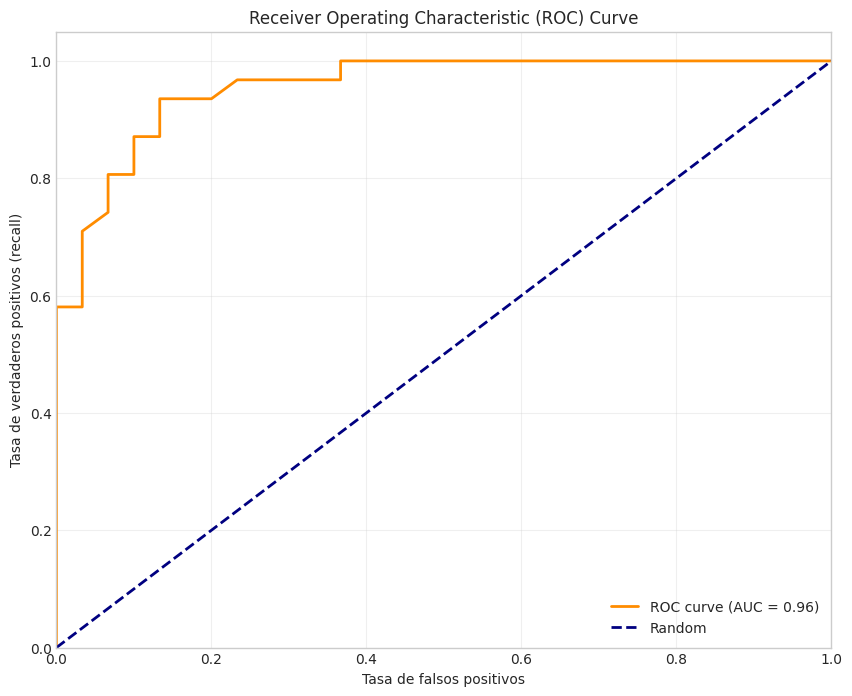

In [0]:
from sklearn.metrics import roc_curve, auc

# ¿Qué es la curva ROC y qué nos dice?: La curva ROC indica que tan bien diferencia las clases el modelo. Muestra una relación entre verdaderos positivos (recall) y falsos positivos
# Obtener probabilidades
y_proba = forest_clf.predict_proba(x_test_pr)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc_curve = auc(fpr, tpr)

plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, color='darkorange', lw=2, 
         label=f'ROC curve (AUC = {roc_auc_curve:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de falsos positivos')
plt.ylabel('Tasa de verdaderos positivos (recall)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

# Feature engineering

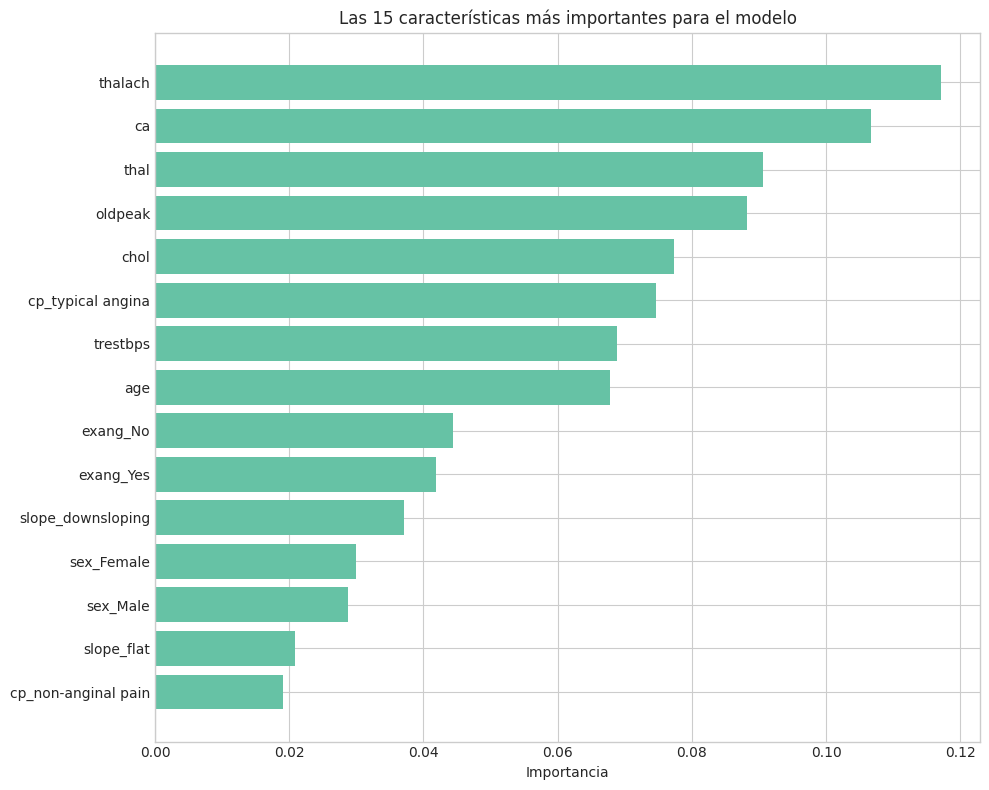

In [0]:
# Observar qué variables son más relevantes para el modelo

# Nombres de las variables
feature_names = num_attr + list(full_pipeline.named_transformers_['cat'].get_feature_names_out(cat_attr))

# Crear dataframe con variables y su importancia para el random fores
feature_importance = pd.DataFrame({
    'feature': feature_names,
    'importance': forest_clf.feature_importances_
}).sort_values('importance', ascending=False)

# Visualizar variables y su importancia
plt.figure(figsize=(10, 8))
plt.barh(
    feature_importance.head(15)['feature'],
    feature_importance.head(15)['importance']
)
plt.xlabel('Importancia')
plt.title('Las 15 características más importantes para el modelo')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [0]:
# 🎨 CÓDIGO DE EJEMPLO PARA LOS DESAFÍOS
# Descomenta y completa para explorar más

# ========================================
# DESAFÍO 1: Grid Search
# ========================================
# from sklearn.model_selection import GridSearchCV
# 
# param_grid = {
#     'n_estimators': [50, 100, 200],
#     'max_depth': [5, 10, 15, None],
#     'min_samples_split': [2, 5, 10],
#     'min_samples_leaf': [1, 2, 4]
# }
# 
# # TODO: [Completa aquí] ¿Qué hace GridSearchCV?
# mlflow.sklearn.autolog()
# with mlflow.start_run(run_name="Grid Search - Random Forest"):
#     grid_search = GridSearchCV(
#         RandomForestClassifier(random_state=42),
#         param_grid,
#         cv=5,
#         scoring='recall',  # Priorizamos recall en medicina
#         verbose=1,
#         n_jobs=-1
#     )
#     grid_search.fit(x_train_pr, y_train)
#     
#     print(f"Mejores parámetros: {grid_search.best_params_}")
#     print(f"Mejor recall (CV): {grid_search.best_score_:.4f}")

# ========================================
# DESAFÍO 2: Curva ROC
# ========================================
# from sklearn.metrics import roc_curve, auc
# 
# # TODO: [Completa aquí] ¿Qué es la curva ROC y qué nos dice?
# # Obtener probabilidades
# y_proba = forest_clf.predict_proba(x_test_pr)[:, 1]
# fpr, tpr, thresholds = roc_curve(y_test, y_proba)
# roc_auc_curve = auc(fpr, tpr)
# 
# plt.figure(figsize=(10, 8))
# plt.plot(fpr, tpr, color='darkorange', lw=2, 
#          label=f'ROC curve (AUC = {roc_auc_curve:.2f})')
# plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random')
# plt.xlim([0.0, 1.0])
# plt.ylim([0.0, 1.05])
# plt.xlabel('False Positive Rate')
# plt.ylabel('True Positive Rate (Recall)')
# plt.title('Receiver Operating Characteristic (ROC) Curve')
# plt.legend(loc="lower right")
# plt.grid(True, alpha=0.3)
# plt.show()

# ========================================
# DESAFÍO 3: Importancia de Características
# ========================================
# # TODO: [Completa aquí] ¿Qué características son más importantes?
# feature_names = num_attr + list(full_pipeline.named_transformers_['cat'].get_feature_names_out(cat_attr))
# feature_importance = pd.DataFrame({
#     'feature': feature_names,
#     'importance': forest_clf.feature_importances_
# }).sort_values('importance', ascending=False)
# 
# plt.figure(figsize=(10, 8))
# plt.barh(feature_importance.head(15)['feature'], 
#          feature_importance.head(15)['importance'])
# plt.xlabel('Importancia')
# plt.title('Top 15 Características Más Importantes')
# plt.gca().invert_yaxis()
# plt.tight_layout()
# plt.show()

# ========================================
# DESAFÍO 4: Comparar Más Modelos
# ========================================
# from sklearn.ensemble import GradientBoostingClassifier
# from sklearn.svm import SVC
# from sklearn.linear_model import LogisticRegression
# 
# modelos = {
#     'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
#     'SVM': SVC(kernel='rbf', probability=True, random_state=42),
#     'Gradient Boosting': GradientBoostingClassifier(random_state=42)
# }
# 
# # TODO: [Completa aquí] ¿Cuál modelo funciona mejor?
# resultados = []
# mlflow.sklearn.autolog()
# 
# for nombre, modelo in modelos.items():
#     with mlflow.start_run(run_name=f"{nombre} - Heart Disease"):
#         modelo.fit(x_train_pr, y_train)
#         preds = modelo.predict(x_test_pr)
#         
#         acc = accuracy_score(y_test, preds)
#         prec = precision_score(y_test, preds)
#         rec = recall_score(y_test, preds)
#         f1_s = f1_score(y_test, preds)
#         
#         resultados.append({
#             'Modelo': nombre,
#             'Accuracy': acc,
#             'Precision': prec,
#             'Recall': rec,
#             'F1-Score': f1_s
#         })
# 
# df_resultados = pd.DataFrame(resultados).sort_values('Recall', ascending=False)
# print("\n📊 Ranking de Modelos (ordenado por Recall):")
# print(df_resultados.to_string(index=False))

# ========================================
# DESAFÍO 5: Análisis de Errores
# ========================================
# # TODO: [Completa aquí] ¿Qué pacientes son difíciles de clasificar?
# # Encontrar errores
# errors_mask = final_preds != y_test
# errors_df = test_set[errors_mask].copy()
# errors_df['prediccion'] = final_preds[errors_mask]
# 
# print(f"\nTotal de errores: {errors_mask.sum()}")
# print(f"\nPacientes mal clasificados:")
# print(errors_df[['age', 'sex', 'cp', 'trestbps', 'chol', 'target', 'prediccion']])
# 
# # Analizar características de los errores
# print("\n¿Los errores tienen características en común?")
# print(errors_df.describe())

print("💡 Descomenta el código del desafío que quieras explorar")